# BipedalWalker：替换 contact 项后的综合 target validation loss

**用 contact changed loss 替换原 contact 项，重新计算综合 target validation loss**：

`target_loss = (8 个连续状态字段的原 MSE + leg1_contact_changed_loss + leg2_contact_changed_loss) / 10`

保留原观察 schema 的等权平均，以及 20 个固定 uniform target 的等权平均。Contact changed 项沿用现有 `val/leg{1,2}_contact_switch_focal_loss`：只在真实接触状态变化的样本上计算 `−(1−p_change) log(p_change) / log(2)`（γ=1）。无切换事件时为 NaN，不填零。

原代码的 `val/<contact>_nll` 是 γ=0 的普通 BCE；旧 `val/observation_loss` 则沿用训练中的 γ=1 全样本 focal objective。这版对两个 contact 字段都直接使用 changed-only focal loss，连续字段不变，最终绘制**综合 target loss**。

DR/MAC 各五个 seed（0–4），最终 checkpoint 均为 50 次 WM 更新。每次 Run All 从保存配置重新验证，每个 target 固定抽取 500 样本，subset seed=0，不启动训练。点为各 seed；粗线和误差棒为均值 ±1 样本标准差。蓝色 DR，橙色 MAC。

MAC seeds 0–2 的历史日志缺失，其他部分日志数值被截断，且没有逐轮 checkpoint，因此这里展示最终模型对比。

In [ ]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "trainer/conf/config_mac.yaml").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从项目目录启动 Jupyter，或将 ROOT 设置为项目绝对路径。")
RUNS = {"DR": ROOT / "test/bipedal_dr/seed0", "MAC": ROOT / "test/bipedal_mac/seed0"}
CSV_PATHS = {
    "DR": RUNS["DR"] / "results/dr/dr_summary_bipedalwalker_mask5_ewc_balanced_inventoryprotect_lp_g1.csv",
    "MAC": RUNS["MAC"] / "results/mac/bipedalwalker_ued_lp_g1_results_mask5.csv",
}
dr_configs = {}
for config_path in sorted(RUNS["DR"].glob("hydra/*/*/.hydra/config.yaml")):
    cfg = yaml.safe_load(config_path.read_text())
    seed = int(cfg["seed"])
    if seed in dr_configs:
        raise ValueError(f"DR seed {seed} 有多份运行配置，请明确选择对应 CSV 的配置。")
    dr_configs[seed] = cfg
seed_configs, frames = {}, {}
for name, path in CSV_PATHS.items():
    df = pd.read_csv(path).sort_values(["Seed", "Iter"]).reset_index(drop=True)
    if df.empty or df.duplicated(["Seed", "Iter"]).any():
        raise ValueError(f"{path}: 需要非空、不重复的 seed/iteration 记录。")
    groups = []
    for seed, group in df.groupby("Seed"):
        seed = int(seed)
        if name == "MAC":
            manifest = path.with_name(f"{path.stem}.seed{seed}.manifest.json")
            cfg = json.loads(manifest.read_text())["config"]
        else:
            cfg = dr_configs[seed]
        if int(cfg["seed"]) != seed:
            raise ValueError(f"{name}: seed {seed} 的配置不匹配。")
        seed_configs[name, seed] = cfg
        if not np.array_equal(group["Iter"].to_numpy(), np.arange(1, len(group) + 1)):
            raise ValueError(f"{path}: seed {seed} 的 iteration 不连续。")
        agent = cfg["generator_agent"]
        if agent["wm_train_frequency"] != 1:
            raise ValueError("当前 notebook 只适用于每轮一次 WM 更新。")
        group = group.copy()
        group["WM_updates"] = (group["Iter"] - int(agent["warmup_iterations"])).clip(lower=0)
        group["Target_loss"] = group["target_val_avg_val_loss_wm"].where(
            (group["WM_updates"] > 0) & (group["target_val_avg_val_loss_wm"] > 0))
        groups.append(group)
        print(f"{name} seed {seed}: {len(group)} rounds | {int(group['WM_updates'].max())} WM updates")
    frames[name] = pd.concat(groups, ignore_index=True)

# 汇总前核对各方法内部的 seed 配置；保存路径允许按 seed 改变。
for name in RUNS:
    seeds = sorted(frames[name]["Seed"].unique())
    reference = seed_configs[name, int(seeds[0])]
    for seed in seeds[1:]:
        cfg = seed_configs[name, int(seed)]
        for section in ["generator_agent", "attention_model"]:
            left = {k: v for k, v in reference[section].items() if k != "model_save_path"}
            right = {k: v for k, v in cfg[section].items() if k != "model_save_path"}
            if left != right:
                raise ValueError(f"{name} seed {seed}: {section} 配置不一致，不能直接汇总。")
        left_collect = {k: v for k, v in reference["env"]["collect"].items() if k != "env_visualize_save_path"}
        right_collect = {k: v for k, v in cfg["env"]["collect"].items() if k != "env_visualize_save_path"}
        if left_collect != right_collect:
            raise ValueError(f"{name} seed {seed}: 数据采集配置不一致。")
        if reference["domains"]["bipedalwalker"] != cfg["domains"]["bipedalwalker"]:
            raise ValueError(f"{name} seed {seed}: BipedalWalker 配置不一致。")
COLORS = {"DR": "tab:blue", "MAC": "tab:orange"}
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})

In [ ]:
import os
import sys
import io
import hashlib
import contextlib
import torch
from omegaconf import OmegaConf, open_dict
from IPython.display import display

for key, value in {
    "TRAINER_ROOT": ROOT, "PROJECT_ROOT": ROOT, "WM_ROOT": ROOT / "wm",
    "WORLD_MODEL_PATH": ROOT / "wm/modelBased", "TRAINER_PATH": ROOT / "trainer",
    "MODEL_FPATH": ROOT / "wm/modelBased/models", "ENV_PATH": ROOT / "level",
    "TRAIN_DATASET_PATH": ROOT / "trainer/data", "GENERATOR_PATH": ROOT / "generator",
}.items():
    os.environ[key] = str(value)
for path in [ROOT, ROOT / "wm"]:
    sys.path.insert(0, str(path))
from modelBased.world_model.AttentionWM import AttentionWorldModel
from trainer.common.utils import set_seed, validate_on_all_targets

torch.set_num_threads(2)
aggregate_rows, target_rows = [], []
reference_targets = None
for name in RUNS:
    for seed in range(5):
        cfg = OmegaConf.create(seed_configs[name, seed])
        domain = cfg.domains.bipedalwalker
        target_dir = Path(str(domain.target_tasks_folder))
        start, count = int(domain.target_task_start_idx), int(domain.target_task_count)
        names = [f"{domain.target_task_prefix}{i}" for i in range(start, start + count)]
        suffix = str(domain.target_task_suffix)
        targets = tuple(str(target_dir / f"{task}{suffix}") for task in names)
        if reference_targets is None:
            reference_targets = targets
        if targets != reference_targets or count != 20 or any(not Path(p).is_file() for p in targets):
            raise ValueError(f"{name} seed {seed}: target datasets differ or are missing")
        if int(cfg.attention_model.target_validation_max_samples) != 500 or int(cfg.attention_model.target_validation_seed) != 0:
            raise ValueError("This comparison requires the original fixed 500-sample targets, subset seed 0")
        checkpoint = Path(str(cfg.attention_model.model_save_path))
        if not checkpoint.is_file():
            raise FileNotFoundError(checkpoint)
        group = frames[name].query("Seed == @seed")
        updates = int(group.WM_updates.max())
        if updates != 50:
            raise ValueError(f"{name} seed {seed}: expected 50 WM updates, found {updates}")
        with open_dict(cfg):
            cfg.attention_model.freeze_weight = True
            cfg.attention_model.use_wandb = False
            cfg.attention_model.n_cpu = 0
            cfg.attention_model.enable_progress_bar = False
        set_seed(seed)
        model = AttentionWorldModel(cfg.attention_model)
        raw = torch.load(checkpoint, map_location="cpu", weights_only=False)
        model.load_state_dict(raw["state_dict"], strict=True)
        model.eval()
        # Suppress Lightning tables; use full-precision returned metrics.
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            summary = validate_on_all_targets(cfg, model, str(target_dir), names, suffix,
                                              phase_name=f"contact_final_{name}_seed{seed}", VALID_TIMES=1)
        if summary["valid_count"] != 20 or not np.isfinite(summary["contact_changed_loss"]):
            raise ValueError(f"{name} seed {seed}: invalid target validation result")
        if not np.isclose(summary["original_avg_val_loss_wm"], group.iloc[-1].target_val_avg_val_loss_wm,
                          rtol=1e-4, atol=1e-5):
            raise ValueError(f"{name} seed {seed}: final checkpoint loss differs from the original CSV")
        identity = {"Method": name, "Seed": seed, "WM_updates": updates,
                    "Checkpoint": str(checkpoint.relative_to(ROOT)),
                    "Checkpoint_sha256": hashlib.sha256(checkpoint.read_bytes()).hexdigest(),
                    "Target_count": count, "Samples_per_target": 500, "Subset_seed": 0}
        aggregate_rows.append({**identity, "Contact_changed_loss": summary["contact_changed_loss"],
                               "Total_validation_loss": summary["avg_val_loss_wm"],
                               "Original_validation_loss": summary["original_avg_val_loss_wm"]})
        for task, metrics in summary["per_target"].items():
            target_rows.append({**identity, "Task": task,
                                "Contact_changed_loss": metrics["contact_changed_loss"],
                                "Total_validation_loss": metrics["avg_val_loss_wm"],
                                "Original_validation_loss": metrics["original_avg_val_loss_wm"]})
        print(f"{name} seed {seed}: target validation loss = {summary['avg_val_loss_wm']:.6f}", flush=True)
        del model, raw

validation = pd.DataFrame(aggregate_rows)
output_dir = ROOT / "outputs/jupyter"
validation.to_csv(output_dir / "bipedal_contact_changed_validation.csv", index=False)
pd.DataFrame(target_rows).to_csv(output_dir / "bipedal_contact_changed_per_target.csv", index=False)
display(validation[["Method", "Seed", "WM_updates", "Contact_changed_loss", "Total_validation_loss"]])


已完成替换 contact 项后的综合 target validation：DR/MAC 各 5 seeds，20 targets × 500 samples。原 objective 已与原 CSV 核对。


Method,Seed,WM_updates,Total_validation_loss,Original_validation_loss
DR,0,50,0.290085,0.050763
DR,1,50,0.250620,0.052561
DR,2,50,0.284578,0.047574
DR,3,50,0.220651,0.052474
DR,4,50,0.239964,0.048106
MAC,0,50,0.230593,0.045261
MAC,1,50,0.237295,0.042882
MAC,2,50,0.228621,0.055207
MAC,3,50,0.231836,0.046675
MAC,4,50,0.224019,0.043366


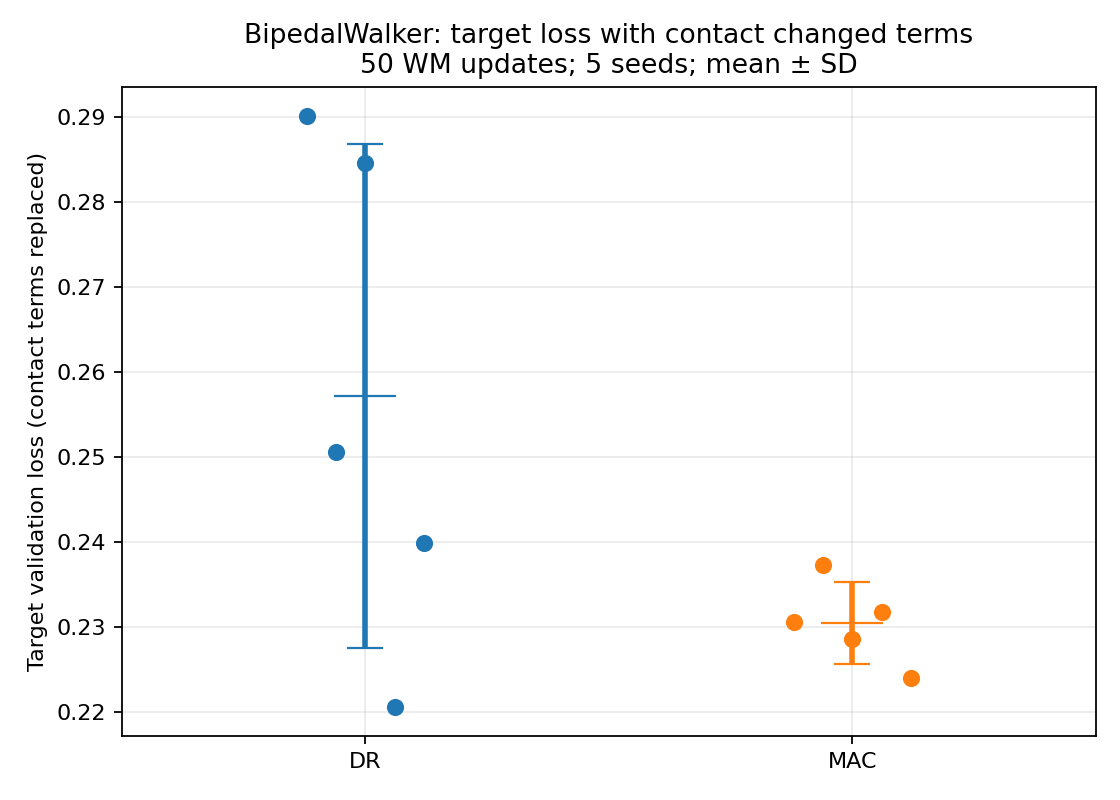

,mean,std,count
Method,,,
DR,0.257179,0.029611,5
MAC,0.230473,0.004835,5


In [ ]:
stats = validation.groupby("Method").Total_validation_loss.agg(["mean", "std", "count"]).reindex(["DR", "MAC"])
fig, ax = plt.subplots(figsize=(7, 5))
for x, name in enumerate(["DR", "MAC"]):
    values = validation.loc[validation.Method == name].sort_values("Seed").Total_validation_loss
    ax.scatter(x + np.linspace(-0.12, 0.12, len(values)), values, color=COLORS[name], s=45, zorder=3)
    ax.errorbar(x, stats.loc[name, "mean"], yerr=stats.loc[name, "std"],
                fmt="_", markersize=28, capsize=8, linewidth=2.5, color=COLORS[name], zorder=4)
ax.set(xticks=[0, 1], xticklabels=["DR", "MAC"], xlim=(-0.5, 1.5),
       title="BipedalWalker: target loss with contact changed terms\n50 WM updates; 5 seeds; mean ± SD",
       ylabel="Target validation loss (contact terms replaced)")
fig.tight_layout()
fig.savefig(output_dir / "bipedal_contact_changed_dr_vs_mac.png", dpi=160)
plt.show()
display(stats)
